# Test các cấu hình Deterministic trên GPU T4

**GPU Target**: NVIDIA Tesla T4  
**Compute Capability**: 7.5  
**TF32 Support**: ❌ Không hỗ trợ (chỉ Ampere+ mới có)

**Mục tiêu**: Test các phương pháp khắc phục vấn đề reproducibility trên GPU T4:
1. Tắt TF32 (T4 không hỗ trợ, nên luôn tắt)
2. Tắt AMP (Automatic Mixed Precision)
3. Tắt cuDNN benchmark
4. Đặt num_workers = 0
5. Bật deterministic algorithms

**Kỳ vọng**: Với các cấu hình này, kết quả sẽ gần giống nhau hơn (nhưng vẫn có thể khác do floating-point precision).


## 1. Kiểm tra GPU và thiết lập môi trường


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os

# Kiểm tra GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {gpu_name}")
    print(f"GPU Compute Capability: {gpu_capability}")

    # Kiểm tra TF32 support (T4 không hỗ trợ)
    print(f"\nTF32 enabled (cuDNN): {torch.backends.cudnn.allow_tf32}")
    if hasattr(torch.backends, 'cublas'):
        print(f"TF32 enabled (cuBLAS): {torch.backends.cublas.allow_tf32}")
    else:
        print("TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)")

    # Xác nhận GPU
    if "T4" not in gpu_name.upper() and "TESLA T4" not in gpu_name.upper():
        print(f"\n⚠️  CẢNH BÁO: GPU hiện tại ({gpu_name}) không phải T4!")
        print("   Notebook này được thiết kế cho Tesla T4.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
    else:
        print(f"\n✓ Đã xác nhận: GPU T4")
else:
    print("❌ Không tìm thấy CUDA GPU!")


PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
cuDNN version: 91002
GPU: Tesla T4
GPU Compute Capability: (7, 5)

TF32 enabled (cuDNN): True
TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)

✓ Đã xác nhận: GPU T4


/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:42: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  return self.getter()


## 2. Định nghĩa các hàm helper


In [2]:
def set_seed(seed=42, deterministic=False):
    """Thiết lập seed với tùy chọn deterministic mode"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        # Lưu ý: use_deterministic_algorithms có thể làm chậm và không hỗ trợ tất cả operations
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms cho tất cả operations")

def setup_environment_deterministic(tf32_enabled=False, amp_enabled=False,
                                     num_workers=4, cudnn_benchmark=False,
                                     deterministic_algorithms=False):
    """
    Thiết lập môi trường với các tùy chọn deterministic

    Args:
        tf32_enabled: Bật/tắt TF32 (T4 không hỗ trợ, nên luôn False)
        amp_enabled: Bật/tắt AMP
        num_workers: Số worker (0 = deterministic, mặc định 4 cho Linux/Unix)
        cudnn_benchmark: Bật/tắt cuDNN benchmark
        deterministic_algorithms: Bật deterministic algorithms (có thể chậm)
    """
    # T4 không hỗ trợ TF32, nên luôn tắt
    torch.backends.cudnn.allow_tf32 = False
    if hasattr(torch.backends, 'cublas'):
        torch.backends.cublas.allow_tf32 = False
    torch.backends.cudnn.benchmark = cudnn_benchmark

    if deterministic_algorithms:
        try:
            torch.use_deterministic_algorithms(True, warn_only=True)
        except:
            print("Warning: Không thể bật use_deterministic_algorithms")

    config = {
        'tf32_enabled': False,  # T4 không hỗ trợ
        'amp_enabled': amp_enabled,
        'num_workers': num_workers,
        'cudnn_benchmark': cudnn_benchmark,
        'deterministic_algorithms': deterministic_algorithms,
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'gpu_capability': torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None
    }

    return config

class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)

        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

def get_cifar10_loaders(batch_size=128, num_workers=4, seed=42):
    """Load CIFAR-10 (tối ưu cho Linux/Unix)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])

    def worker_init_fn(worker_id):
        np.random.seed(seed + worker_id)

    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, worker_init_fn=worker_init_fn if num_workers > 0 else None,
        pin_memory=True
    )

    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        pin_memory=True
    )

    return trainloader, testloader


## 3. Hàm training


In [3]:
def train_model(config, seed=42, num_epochs=10, save_results=True):
    """Train mô hình với cấu hình cụ thể"""
    set_seed(seed, deterministic=config.get('deterministic_algorithms', False))
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    trainloader, testloader = get_cifar10_loaders(
        batch_size=128,
        num_workers=config['num_workers'],
        seed=seed
    )

    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'config': config,
        'seed': seed
    }

    scaler = torch.cuda.amp.GradScaler() if config['amp_enabled'] else None

    print(f"\n{'='*70}")
    print(f"GPU: {config['gpu_name']}")
    print(f"Config: TF32={config['tf32_enabled']} (T4 không hỗ trợ), AMP={config['amp_enabled']}, "
          f"Workers={config['num_workers']}, Benchmark={config['cudnn_benchmark']}, "
          f"Deterministic={config.get('deterministic_algorithms', False)}")
    print(f"{'='*70}\n")

    for epoch in range(num_epochs):
        # Train
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            if config['amp_enabled'] and scaler is not None:
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()

        train_loss /= len(trainloader)
        train_acc = 100. * train_correct / train_total

        # Test
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                test_loss += loss.item()
                _, predicted = outputs.max(1)
                test_total += labels.size(0)
                test_correct += predicted.eq(labels).sum().item()

        test_loss /= len(testloader)
        test_acc = 100. * test_correct / test_total

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)

        print(f"Epoch {epoch+1}/{num_epochs}: "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
              f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        gpu_name_short = config['gpu_name'].replace(' ', '_').replace('NVIDIA ', '').replace('Tesla ', '')
        config_str = f"tf32_{config['tf32_enabled']}_amp_{config['amp_enabled']}_w{config['num_workers']}_bench{config['cudnn_benchmark']}_det{config.get('deterministic_algorithms', False)}"
        filename = f"results/deterministic_{gpu_name_short}_{config_str}_{timestamp}.json"

        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")

    return history


In [4]:
# Config 1: Mặc định (TF32 tắt vì T4 không hỗ trợ, cuDNN benchmark bật, 4 workers)
config_default = setup_environment_deterministic(
    tf32_enabled=False,  # T4 không hỗ trợ
    amp_enabled=False,
    num_workers=4,
    cudnn_benchmark=True,
    deterministic_algorithms=False
)
history_default = train_model(config_default, seed=42, num_epochs=10)


100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(



GPU: Tesla T4
Config: TF32=False (T4 không hỗ trợ), AMP=False, Workers=4, Benchmark=True, Deterministic=False

Epoch 1/10: Train Loss: 1.4518, Train Acc: 46.72% | Test Loss: 1.1012, Test Acc: 60.23%
Epoch 2/10: Train Loss: 1.1351, Train Acc: 59.17% | Test Loss: 0.9539, Test Acc: 65.79%
Epoch 3/10: Train Loss: 1.0188, Train Acc: 63.47% | Test Loss: 0.8582, Test Acc: 69.15%
Epoch 4/10: Train Loss: 0.9416, Train Acc: 66.36% | Test Loss: 0.8289, Test Acc: 70.72%
Epoch 5/10: Train Loss: 0.8950, Train Acc: 68.42% | Test Loss: 0.7771, Test Acc: 72.92%
Epoch 6/10: Train Loss: 0.8482, Train Acc: 70.01% | Test Loss: 0.7436, Test Acc: 73.27%
Epoch 7/10: Train Loss: 0.8246, Train Acc: 70.82% | Test Loss: 0.7479, Test Acc: 73.82%
Epoch 8/10: Train Loss: 0.7982, Train Acc: 71.55% | Test Loss: 0.6905, Test Acc: 75.88%
Epoch 9/10: Train Loss: 0.7663, Train Acc: 72.84% | Test Loss: 0.6658, Test Acc: 76.47%
Epoch 10/10: Train Loss: 0.7482, Train Acc: 73.59% | Test Loss: 0.6656, Test Acc: 76.45%

✓ Kết 

### 4.2 Tắt cuDNN benchmark


In [5]:
# Config 2: Tắt cuDNN benchmark
config_no_benchmark = setup_environment_deterministic(
    tf32_enabled=False,  # T4 không hỗ trợ
    amp_enabled=False,
    num_workers=4,
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_no_benchmark = train_model(config_no_benchmark, seed=42, num_epochs=10)



GPU: Tesla T4
Config: TF32=False (T4 không hỗ trợ), AMP=False, Workers=4, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4512, Train Acc: 46.73% | Test Loss: 1.0974, Test Acc: 60.34%
Epoch 2/10: Train Loss: 1.1320, Train Acc: 59.20% | Test Loss: 0.9228, Test Acc: 67.35%
Epoch 3/10: Train Loss: 1.0173, Train Acc: 63.82% | Test Loss: 0.8728, Test Acc: 69.18%
Epoch 4/10: Train Loss: 0.9428, Train Acc: 66.32% | Test Loss: 0.8345, Test Acc: 70.65%
Epoch 5/10: Train Loss: 0.8943, Train Acc: 68.37% | Test Loss: 0.7640, Test Acc: 73.61%
Epoch 6/10: Train Loss: 0.8524, Train Acc: 69.70% | Test Loss: 0.7248, Test Acc: 74.30%
Epoch 7/10: Train Loss: 0.8240, Train Acc: 70.82% | Test Loss: 0.7424, Test Acc: 73.81%
Epoch 8/10: Train Loss: 0.7962, Train Acc: 71.84% | Test Loss: 0.6744, Test Acc: 76.12%
Epoch 9/10: Train Loss: 0.7672, Train Acc: 72.96% | Test Loss: 0.6598, Test Acc: 76.91%
Epoch 10/10: Train Loss: 0.7459, Train Acc: 73.78% | Test Loss: 0.6718, Test Acc: 76.67%

✓ Kết

### 4.3 num_workers = 0


In [6]:
# Config 3: num_workers = 0
config_no_workers = setup_environment_deterministic(
    tf32_enabled=False,  # T4 không hỗ trợ
    amp_enabled=False,
    num_workers=0,
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_no_workers = train_model(config_no_workers, seed=42, num_epochs=10)



GPU: Tesla T4
Config: TF32=False (T4 không hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4549, Train Acc: 46.46% | Test Loss: 1.1670, Test Acc: 58.16%
Epoch 2/10: Train Loss: 1.1282, Train Acc: 59.57% | Test Loss: 1.0534, Test Acc: 62.00%
Epoch 3/10: Train Loss: 1.0122, Train Acc: 64.01% | Test Loss: 0.8561, Test Acc: 69.81%
Epoch 4/10: Train Loss: 0.9408, Train Acc: 66.46% | Test Loss: 0.8222, Test Acc: 70.72%
Epoch 5/10: Train Loss: 0.8916, Train Acc: 68.21% | Test Loss: 0.7580, Test Acc: 73.53%
Epoch 6/10: Train Loss: 0.8515, Train Acc: 69.92% | Test Loss: 0.7509, Test Acc: 73.16%
Epoch 7/10: Train Loss: 0.8180, Train Acc: 71.03% | Test Loss: 0.7099, Test Acc: 74.97%
Epoch 8/10: Train Loss: 0.7954, Train Acc: 71.81% | Test Loss: 0.6945, Test Acc: 75.87%
Epoch 9/10: Train Loss: 0.7632, Train Acc: 73.12% | Test Loss: 0.6929, Test Acc: 75.93%
Epoch 10/10: Train Loss: 0.7448, Train Acc: 73.44% | Test Loss: 0.6474, Test Acc: 77.59%

✓ Kết

### 4.4 Cấu hình tối đa deterministic (tất cả tắt/bật)


In [7]:
# Config 4: Tối đa deterministic
config_max_deterministic = setup_environment_deterministic(
    tf32_enabled=False,  # T4 không hỗ trợ
    amp_enabled=False,
    num_workers=0,
    cudnn_benchmark=False,
    deterministic_algorithms=True
)
history_max_deterministic = train_model(config_max_deterministic, seed=42, num_epochs=10)



GPU: Tesla T4
Config: TF32=False (T4 không hỗ trợ), AMP=False, Workers=0, Benchmark=False, Deterministic=True



/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:841: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:315.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 1/10: Train Loss: 1.4559, Train Acc: 46.51% | Test Loss: 1.1681, Test Acc: 57.57%
Epoch 2/10: Train Loss: 1.1288, Train Acc: 59.40% | Test Loss: 0.9986, Test Acc: 64.20%
Epoch 3/10: Train Loss: 1.0126, Train Acc: 63.99% | Test Loss: 0.8588, Test Acc: 69.92%
Epoch 4/10: Train Loss: 0.9408, Train Acc: 66.61% | Test Loss: 0.8170, Test Acc: 71.31%
Epoch 5/10: Train Loss: 0.8901, Train Acc: 68.51% | Test Loss: 0.7718, Test Acc: 72.97%
Epoch 6/10: Train Loss: 0.8485, Train Acc: 70.08% | Test Loss: 0.7569, Test Acc: 72.95%
Epoch 7/10: Train Loss: 0.8206, Train Acc: 70.98% | Test Loss: 0.7250, Test Acc: 74.21%
Epoch 8/10: Train Loss: 0.7920, Train Acc: 71.93% | Test Loss: 0.6981, Test Acc: 75.59%
Epoch 9/10: Train Loss: 0.7658, Train Acc: 73.16% | Test Loss: 0.6801, Test Acc: 76.00%
Epoch 10/10: Train Loss: 0.7437, Train Acc: 73.77% | Test Loss: 0.6409, Test Acc: 77.68%

✓ Kết quả đã lưu: results/deterministic_Tesla_T4_tf32_False_amp_False_w0_benchFalse_detTrue_20251226_075756.json


### 4.5 Test với AMP (Automatic Mixed Precision)


In [8]:
# Config 5: Với AMP (để thấy sự khác biệt)
config_amp = setup_environment_deterministic(
    tf32_enabled=False,  # T4 không hỗ trợ
    amp_enabled=True,
    num_workers=0,
    cudnn_benchmark=False,
    deterministic_algorithms=False
)
history_amp = train_model(config_amp, seed=42, num_epochs=10)


/tmp/ipython-input-1262070066.py:25: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if config['amp_enabled'] else None
/tmp/ipython-input-1262070066.py:46: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



GPU: Tesla T4
Config: TF32=False (T4 không hỗ trợ), AMP=True, Workers=0, Benchmark=False, Deterministic=False

Epoch 1/10: Train Loss: 1.4520, Train Acc: 46.66% | Test Loss: 1.1018, Test Acc: 59.86%
Epoch 2/10: Train Loss: 1.1401, Train Acc: 59.14% | Test Loss: 0.9804, Test Acc: 64.79%
Epoch 3/10: Train Loss: 1.0202, Train Acc: 63.56% | Test Loss: 0.8541, Test Acc: 70.17%
Epoch 4/10: Train Loss: 0.9470, Train Acc: 66.35% | Test Loss: 0.7906, Test Acc: 72.24%
Epoch 5/10: Train Loss: 0.8978, Train Acc: 68.23% | Test Loss: 0.7807, Test Acc: 72.51%
Epoch 6/10: Train Loss: 0.8547, Train Acc: 69.74% | Test Loss: 0.7793, Test Acc: 72.78%
Epoch 7/10: Train Loss: 0.8240, Train Acc: 70.80% | Test Loss: 0.7018, Test Acc: 75.66%
Epoch 8/10: Train Loss: 0.8002, Train Acc: 71.82% | Test Loss: 0.6743, Test Acc: 76.59%
Epoch 9/10: Train Loss: 0.7743, Train Acc: 72.68% | Test Loss: 0.7166, Test Acc: 75.22%
Epoch 10/10: Train Loss: 0.7449, Train Acc: 73.69% | Test Loss: 0.6436, Test Acc: 77.73%

✓ Kết 

## 5. So sánh tất cả các cấu hình trên GPU T4


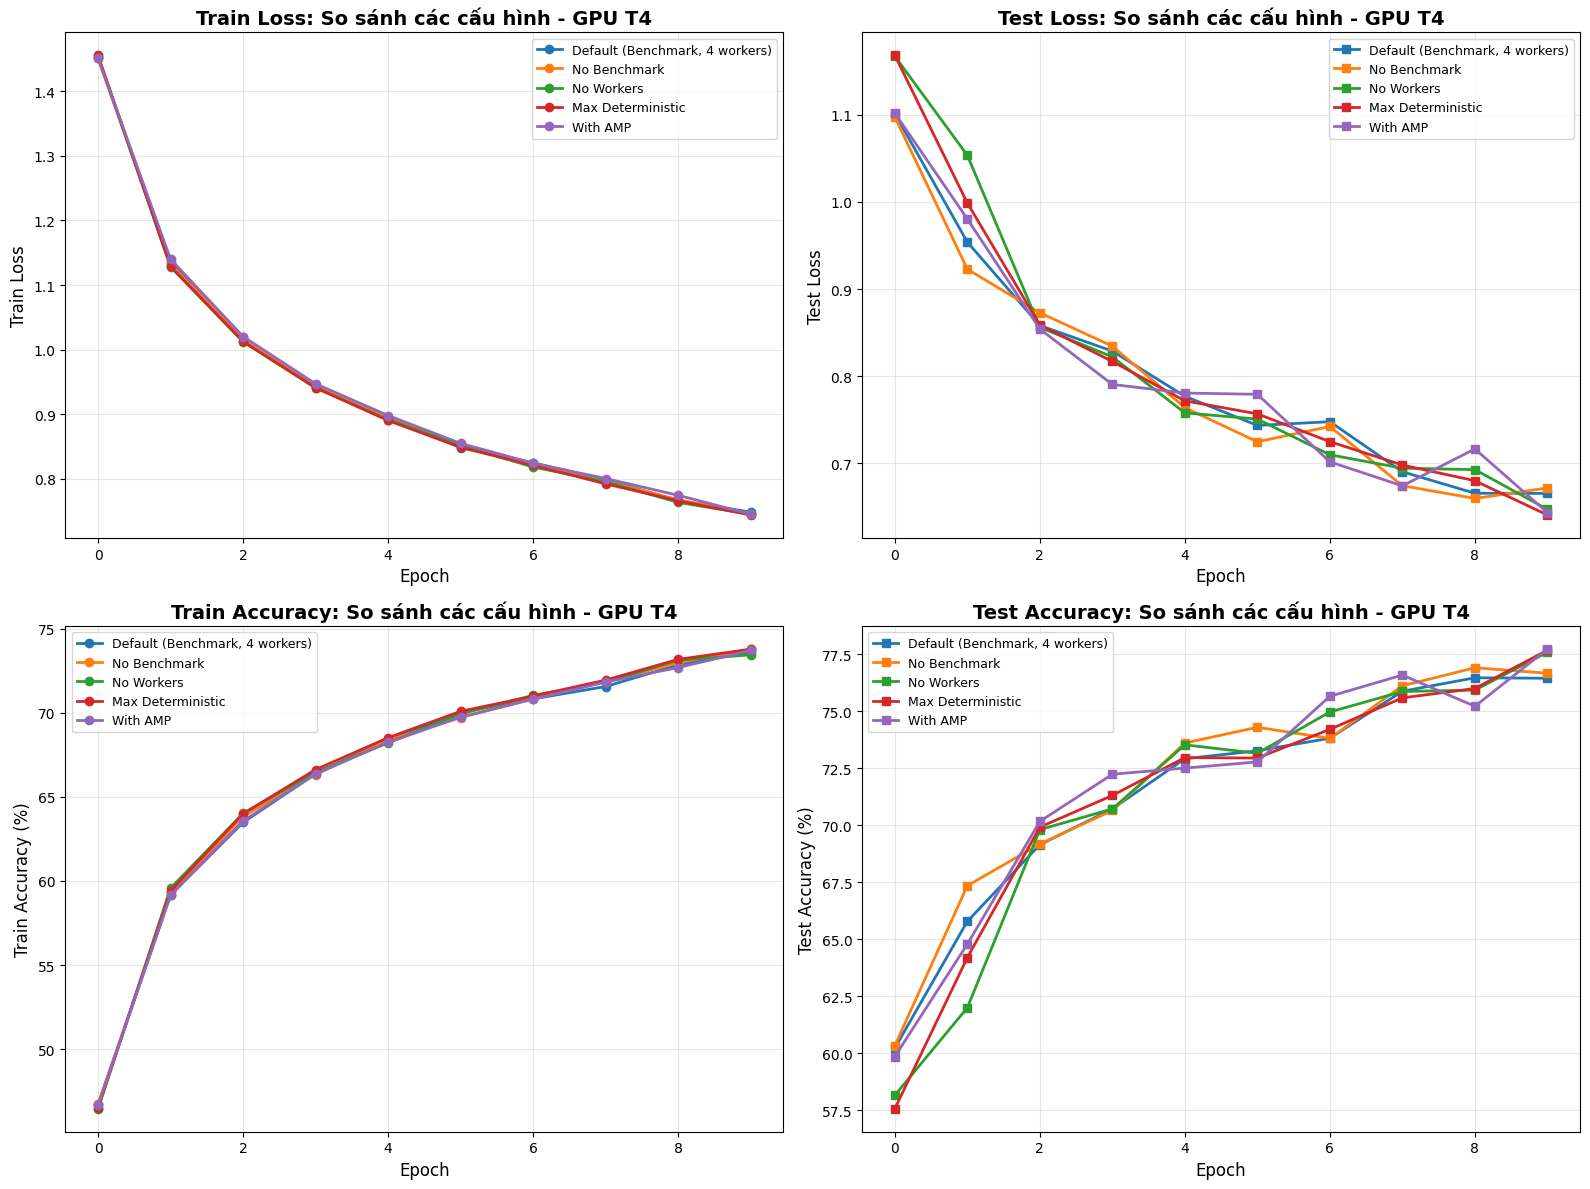


BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - GPU T4
Cấu hình                                           Train Loss   Test Loss    Test Acc    
----------------------------------------------------------------------------------------------------
Default (Benchmark, 4 workers)                     0.7482       0.6656       76.45       %
No Benchmark                                       0.7459       0.6718       76.67       %
No Workers                                         0.7448       0.6474       77.59       %
Max Deterministic                                  0.7437       0.6409       77.68       %
With AMP                                           0.7449       0.6436       77.73       %

PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)
Cấu hình                                           Test Acc     Độ lệch     
----------------------------------------------------------------------------------------------------
Default (Benchmark, 4 workers)                     76.45       % -1.23%
No Benc

In [9]:
def compare_all_configs(histories, labels):
    """So sánh tất cả các cấu hình"""
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Loss', fontsize=12)
    ax.set_title('Train Loss: So sánh các cấu hình - GPU T4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Loss', fontsize=12)
    ax.set_title('Test Loss: So sánh các cấu hình - GPU T4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Train Accuracy (%)', fontsize=12)
    ax.set_title('Train Accuracy: So sánh các cấu hình - GPU T4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax.set_title('Test Accuracy: So sánh các cấu hình - GPU T4', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/deterministic_configs_comparison_T4.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Bảng so sánh
    print("\n" + "="*100)
    print("BẢNG SO SÁNH TẤT CẢ CẤU HÌNH - GPU T4")
    print("="*100)
    print(f"{'Cấu hình':<50} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-"*100)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<50} {final_train_loss:<12.4f} {final_test_loss:<12.4f} {final_test_acc:<12.2f}%")
    print("="*100)

    # Phân tích độ lệch
    print("\n" + "="*100)
    print("PHÂN TÍCH ĐỘ LỆCH (so với cấu hình tối đa deterministic)")
    print("="*100)
    if len(histories) > 0:
        baseline = histories[-2]  # Max deterministic (trước AMP)
        baseline_test_acc = baseline['test_acc'][-1]

        print(f"{'Cấu hình':<50} {'Test Acc':<12} {'Độ lệch':<12}")
        print("-"*100)
        for hist, label in zip(histories, labels):
            test_acc = hist['test_acc'][-1]
            diff = test_acc - baseline_test_acc
            print(f"{label:<50} {test_acc:<12.2f}% {diff:+.2f}%")
    print("="*100)

# So sánh
all_histories = [
    history_default,
    history_no_benchmark,
    history_no_workers,
    history_max_deterministic,
    history_amp
]

all_labels = [
    "Default (Benchmark, 4 workers)",
    "No Benchmark",
    "No Workers",
    "Max Deterministic",
    "With AMP"
]

compare_all_configs(all_histories, all_labels)


## 6. Kết luận cho GPU T4

**Đặc điểm GPU T4**:
- Compute Capability: 7.5 (Turing architecture)
- ❌ Không hỗ trợ TF32 (chỉ Ampere+ mới có)
- ✅ Hỗ trợ FP32 và FP16 (với AMP)

**Quan sát từ các test trên T4**:

1. **TF32**: T4 không hỗ trợ TF32, nên không có test này
2. **cuDNN Benchmark**: Tắt benchmark giúp deterministic hơn nhưng có thể chậm hơn
3. **num_workers**: Đặt = 0 loại bỏ non-determinism từ DataLoader
4. **Deterministic Algorithms**: Giúp reproducibility tốt nhất nhưng có thể chậm và không hỗ trợ tất cả operations
5. **AMP**: Mixed precision có thể gây khác biệt về kết quả do precision thấp hơn

**Khuyến nghị cho T4**:
- Để reproducibility tốt nhất: Tắt benchmark, num_workers=0, bật deterministic algorithms
- Để performance tốt nhất: Bật benchmark, nhiều workers
- Cân bằng: Tắt benchmark, num_workers=0 (chấp nhận chậm hơn một chút)

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/` với tên GPU T4
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (L4, A100, RTX 3060, H100)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh
